# 입문 실습: 표본으로 시작하는 Nemotron-Personas-Korea

NVIDIA가 공개한 한국형 합성 페르소나 데이터를 **작은 표본**으로 열어 본다. 1차시(파이썬을 활용한 기초통계 분석)에서 배운 pandas 문법만 쓴다.

- **대상**: 1차시를 마친 사람. `read_csv`, `head`, `describe`, `value_counts`를 써 봤으면 된다.
- **내려받기가 없다.** 데이터는 사이트에 올려 둔 표본 파일(1만 명, 7,500명)을 인터넷에서 바로 읽는다.
- **`dept`(학과)와 `job`(직무) 컬럼은 학습용으로 덧붙인 것이다.** 원본 데이터에는 없다. 자세한 규칙은 [표본 설명](https://kwonsuhyeon.github.io/personaex/data/README.md)에 있다.
- 실행 방법: 위에서부터 셀을 하나씩 실행한다(Shift+Enter). 커널은 pandas가 설치된 것이면 무엇이든 된다.

전체 데이터(100만 명)로 더 해 보고 싶으면 마지막 절 "더 해 보기"를 본다.

## 0. 준비

pandas가 없으면 명령 프롬프트(cmd)에서 `pip install pandas pyarrow matplotlib`를 한 번 실행한다. `pyarrow`는 parquet 파일을 읽는 데 필요하다.

macOS라면 아래 셀의 글꼴 이름 `Malgun Gothic`을 `AppleGothic`으로 바꾼다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"   # 그림에 한글이 나오게 한다
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호가 깨지지 않게 한다
pd.set_option("display.max_columns", 30)         # 표의 컬럼이 생략되지 않게 한다

## 1. 데이터 열기

`BASE_URL`은 표본 파일이 있는 곳이다. 사이트 반영 전에 로컬에서 돌리려면 이 값을 `"../docs/data/"`로 바꾸면 된다.

In [2]:
BASE_URL = "https://kwonsuhyeon.github.io/personaex/data/"

df = pd.read_parquet(BASE_URL + "sample_random.parquet")
df.shape     # (행 수, 컬럼 수)

(10000, 26)

1만 명, 26개 컬럼이다. 컬럼은 세 묶음이다.

| 묶음 | 컬럼 | 만든 방식 |
|---|---|---|
| 인구통계 변수 (12개) | `sex`, `age`, `marital_status`, `military_status`, `family_type`, `housing_type`, `education_level`, `bachelors_field`, `occupation`, `district`, `province`, `country` | 공식 통계로 만든 확률 모형에서 뽑은 값 |
| 속성 (6개) | `cultural_background`, `skills_and_expertise`(+`_list`), `hobbies_and_interests`(+`_list`), `career_goals_and_ambitions` | LLM이 쓴 서술 |
| 페르소나 서술문 (7개) | `persona`, `professional_persona`, `sports_persona`, `arts_persona`, `travel_persona`, `culinary_persona`, `family_persona` | LLM이 쓴 서술 |

## 2. 컬럼과 자료형

In [3]:
df.dtypes    # 컬럼마다 자료형. object는 문자열, int64는 정수

uuid                          object
professional_persona          object
sports_persona                object
arts_persona                  object
travel_persona                object
culinary_persona              object
family_persona                object
persona                       object
cultural_background           object
skills_and_expertise          object
skills_and_expertise_list     object
hobbies_and_interests         object
hobbies_and_interests_list    object
career_goals_and_ambitions    object
sex                           object
age                            int64
marital_status                object
military_status               object
family_type                   object
housing_type                  object
education_level               object
bachelors_field               object
occupation                    object
district                      object
province                      object
country                       object
dtype: object

숫자 컬럼은 `age` 하나뿐이다. 나머지는 모두 글자다. 처음 3명을 본다.

In [4]:
df.head(3)

,uuid,professional_persona,sports_persona,arts_persona,travel_persona,culinary_persona,family_persona,persona,cultural_background,skills_and_expertise,skills_and_expertise_list,hobbies_and_interests,hobbies_and_interests_list,career_goals_and_ambitions,sex,age,marital_status,military_status,family_type,housing_type,education_level,bachelors_field,occupation,district,province,country
0,03b4f36a18e6469386d0286dddd513c8,"전기태 씨는 광주 서구의 하역 현장에서 수십 년간 짐을 쌓아 올리며, 지렛대 원리를...","전기태 씨는 주말마다 무등산 자락을 느릿느릿 걸으며 땀을 흘리고, 내려오는 길에 단...",전기태 씨는 거실 소파에 깊숙이 파묻혀 텔레비전에서 나오는 옛날 가요 프로그램을 보...,전기태 씨는 아내와 함께 전국의 역사 유적지를 찾아다니며 옛 조상들의 발취를 느끼는...,전기태 씨는 일주일에 한 번 배달 짜장면과 탕수육을 시켜 먹는 날을 손꼽아 기다리며...,"전기태 씨는 전·월세 아파트에서 평생의 동반자인 아내와 단출하게 살아가며, 투박한 ...","전기태 씨는 광주 서구에서 평생 하역 일을 하며 살아온 70대 가장으로, 투박한 손...","광주 서구에서 평생을 보내며 투박하지만 정겨운 전라도 사투리가 몸에 배어 있고, 시...",수십 년간 하역 현장에서 다져진 감각으로 짐의 무게 중심을 한눈에 파악해 가장 효율...,"['적재물 무게 중심 파악 및 효율적 배치', '현장 자재 결속 및 고정 기술', ...","주말이면 무등산 자락을 천천히 걸으며 땀을 빼고, 내려오는 길에 단골 목욕탕에서 뜨...","['무등산 둘레길 산책', '동네 대중사우나 이용', '전통시장 맛집 탐방', '트...",큰 욕심 없이 지금처럼 매일 아침 정해진 시간에 출근해 땀 흘려 일하며 건강을 유지...,남자,74,배우자있음,비현역,배우자와 거주,아파트,초등학교,해당없음,하역 및 적재 관련 단순 종사원,광주-서구,광주,대한민국
1,2962168f0b8146939656d30d6dfaeb79,김보경 씨는 법과 경영을 전공해 복잡한 계약서의 독소 조항을 빠르게 잡아내는 능력이...,김보경 씨는 격렬한 운동 대신 오산천 산책길을 천천히 걸으며 생각을 정리하는 것을 ...,김보경 씨는 니콘 카메라를 들고 조용한 숲길의 빛과 그림자를 포착하는 사진 작업에 ...,김보경 씨는 주말이면 친한 친구들과 함께 강원도 인제나 평창의 깊은 산세를 찾아가 ...,김보경 씨는 일주일에 대여섯 번 동네 단골 일식집을 찾아 두툼한 등심 돈카츠를 주문...,"김보경 씨는 부모님과 함께 전세 아파트에서 거주하며, 평소에는 무뚝뚝해 보이지만 집...","김보경 씨는 실리와 안정을 최우선으로 여기는 23세 취준생으로, 철저한 지출 관리와...","오산천 주변의 한적한 분위기 속에 살아왔으며, 대학 졸업 후 취업 준비 기간이 길어...","복잡한 약관이나 계약서에서 자신에게 불리한 조항을 빠르게 찾아내며, 엑셀을 활용해 ...","['계약서 독소 조항 분석', '엑셀 기반 지출 관리', '행정 문서 기초 작성',...","주말에는 친구들과 함께 조용한 숲길이나 바닷가를 찾아 다니며 풍경 사진을 남기고, ...","['풍경 사진 촬영', '콘솔 게임', '오산천 산책', '일식 맛집 탐방']",사회적 명성보다는 정시 퇴근이 확실하고 업무 범위가 명확한 경기도 인근의 기업 사무...,남자,23,미혼,비현역,기타2세대,아파트,4년제 대학교,경영·행정·법,무직,경기-오산시,경기,대한민국
2,34bada25384640f89713dc494274b1b5,이나우엘 씨는 천안의 금융 창구에서 꼼꼼하게 시재를 맞추던 손끝 감각을 여전히 기억...,이나우엘 씨는 집 근처 배드민턴 코트에서 셔틀콕을 주고받으며 머릿속을 가득 채운 잡...,이나우엘 씨는 불당동의 세련된 카페 거리와 구도심의 낡은 풍경이 교차하는 천안의 거...,이나우엘 씨는 과거 금융권 근무 시절 업무상 필요해 다녔던 여러 지역의 시찰과 회의...,이나우엘 씨는 일주일에 네 번 이상 동네 고깃집을 찾아 지글거리는 삼겹살에 소주 한...,"이나우엘 씨는 배우자와 별거하며 천안의 아파트에서 홀로 지내고 있으며, 적막한 집 ...","이나우엘 씨는 금융권의 정중함을 몸에 익힌 전직 사무원이었으나, 현재는 별거와 실직...","천안 불당동의 세련된 도시 분위기와 구도심의 투박함 사이에서 성장했으며, 금융권에서...",창구에서 다양한 고객의 요구사항을 유연하게 조율하며 불만을 잠재우는 소통 능력이 탁...,"['정확한 현금 시재 및 마감 관리', '고객 민원 응대 및 갈등 조율', '금융 ...","유튜브에서 스포츠 분석 영상을 보며 소액의 배팅을 즐기거나, 집 근처 배드민턴 코트...","['스포츠 경기 분석 및 소액 배팅', '동네 배드민턴 클럽 활동', '모바일 전략...","당장의 거창한 성공보다는 규칙적인 일과를 되찾아 정서적 불안감을 해소하고, 누군가에...",남자,36,배우자있음,비현역,혼자 거주 (배우자 별거),아파트,2~3년제 전문대학,해당없음,"전직 출납 창구 사무원, 현재 구직중",충청남-천안시 서북구,충청남,대한민국


서술문 컬럼이 길어서 표가 넓다. 인구통계 변수만 골라 다시 본다.

In [5]:
demo_cols = ["sex", "age", "marital_status", "education_level", "bachelors_field", "occupation", "province"]
df[demo_cols].head(5)

,sex,age,marital_status,education_level,bachelors_field,occupation,province
0,남자,74,배우자있음,초등학교,해당없음,하역 및 적재 관련 단순 종사원,광주
1,남자,23,미혼,4년제 대학교,경영·행정·법,무직,경기
2,남자,36,배우자있음,2~3년제 전문대학,해당없음,"전직 출납 창구 사무원, 현재 구직중",충청남
3,여자,32,배우자있음,4년제 대학교,서비스,전화 상담원,광주
4,남자,48,배우자있음,중학교,해당없음,하역 및 적재 관련 단순 종사원,경상남


## 3. 기초통계

### 3-1. 빈 값이 있는가

In [6]:
df.isna().sum()    # 컬럼마다 빈 값(NaN)의 개수

uuid                          0
professional_persona          0
sports_persona                0
arts_persona                  0
travel_persona                0
culinary_persona              0
family_persona                0
persona                       0
cultural_background           0
skills_and_expertise          0
skills_and_expertise_list     0
hobbies_and_interests         0
hobbies_and_interests_list    0
career_goals_and_ambitions    0
sex                           0
age                           0
marital_status                0
military_status               0
family_type                   0
housing_type                  0
education_level               0
bachelors_field               0
occupation                    0
district                      0
province                      0
country                       0
dtype: int64

빈 값이 하나도 없다. 합성 데이터라 모든 칸이 채워져 있다.

### 3-2. 나이

In [7]:
df["age"].describe()    # 개수, 평균, 표준편차, 최소, 사분위수, 최대

count    10000.000000
mean        50.346400
std         17.633307
min         19.000000
25%         36.000000
50%         51.000000
75%         63.000000
max         99.000000
Name: age, dtype: float64

19세 이하는 없다. 이 데이터는 성인만 다룬다. 성별로 나눠 히스토그램을 그린다.

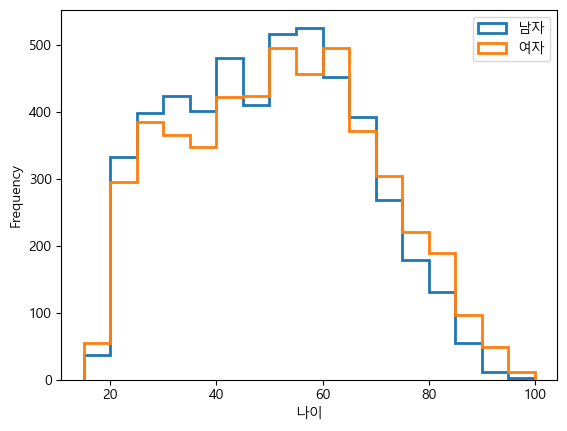

In [8]:
df[df["sex"] == "남자"]["age"].plot.hist(bins=range(15, 105, 5), histtype="step", linewidth=2, label="남자")
df[df["sex"] == "여자"]["age"].plot.hist(bins=range(15, 105, 5), histtype="step", linewidth=2, label="여자")
plt.legend()
plt.xlabel("나이")
plt.show()

### 3-3. 범주형 변수의 비율

`value_counts(normalize=True)`는 개수 대신 비율을 준다. 100을 곱해 %로 본다.

In [9]:
df["sex"].value_counts(normalize=True) * 100

sex
남자    50.16
여자    49.84
Name: proportion, dtype: float64

In [10]:
df["education_level"].value_counts(normalize=True) * 100

education_level
고등학교          32.17
4년제 대학교       28.24
2~3년제 전문대학    15.01
중학교            8.40
초등학교           7.96
대학원            5.65
무학             2.57
Name: proportion, dtype: float64

고등학교와 4년제 대학교가 많다. 학력 비율을 막대그림으로 본다.

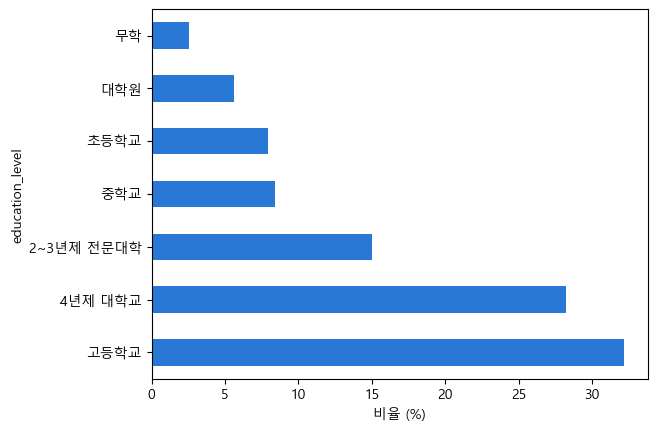

In [11]:
(df["education_level"].value_counts(normalize=True) * 100).plot.barh(color="#2a78d6")
plt.xlabel("비율 (%)")
plt.show()

In [12]:
df["province"].value_counts().head(10)    # 시도별 인원, 많은 순 10개

province
경기     2606
서울     1883
부산      677
경상남     652
인천      574
경상북     549
충청남     443
대구      423
전북      354
전라남     315
Name: count, dtype: int64

표본이라 이 비율은 전체(100만 명)와 1%p 안팎 다를 수 있다. 전체 수치는 [이해 보고서](https://kwonsuhyeon.github.io/personaex/report.html)에 있다.

### 3-4. 두 변수를 함께 보기: 교차표

`pd.crosstab`은 두 범주형 변수의 조합별 인원을 표로 만든다. `normalize="index"`는 행마다 합이 1이 되게 한다.

In [13]:
pd.crosstab(df["sex"], df["education_level"], normalize="index").round(3) * 100

education_level,2~3년제 전문대학,4년제 대학교,고등학교,대학원,무학,중학교,초등학교
sex,,,,,,,
남자,15.8,31.6,31.9,6.8,1.0,7.7,5.1
여자,14.2,24.9,32.4,4.5,4.2,9.1,10.8


행이 성별, 열이 학력이다. 남자와 여자의 학력 분포가 다르게 나오는지 본다.

### 3-5. 직업

직업 컬럼은 값이 2,000가지가 넘는다. 먼저 `무직`이 얼마나 되는지, `전직 ○○, 현재 구직중` 같은 값이 있는지 본다.

In [14]:
df["occupation"].value_counts().head(10)

occupation
무직                   3638
건물 경비원                190
건물 청소원                170
경리 사무원                146
사무 보조원                145
일반 비서                 109
시설 경비원                109
전화 상담원                107
하역 및 적재 관련 단순 종사원     104
그 외 일반 영업원             80
Name: count, dtype: int64

In [15]:
(df["occupation"] == "무직").sum()                            # 무직인 사람 수

np.int64(3638)

In [16]:
df["occupation"].str.contains("현재 구직중").sum()             # 직업명에 "현재 구직중"이 들어간 사람 수

np.int64(278)

`무직`이 가장 큰 단일 값이다. 주부, 학생, 은퇴자, 실업자가 구분되지 않는다는 뜻이다. 취업자만 남기려면 이 둘을 뺀다.

In [17]:
employed = df[(df["occupation"] != "무직") & ~df["occupation"].str.contains("현재 구직중")]
len(employed), len(df)

(6084, 10000)

## 4. 학과·직무별로 보기

두 번째 표본 파일은 다섯 학과(기계공학, 메카트로닉스, 컴퓨터공학, 데이터경영, 고용서비스정책)와 관련된 직무를 가진 사람만 모은 것이다. 직무마다 500명씩이다.

`dept`와 `job` 두 컬럼은 **학습용으로 덧붙인 것**이다. 직업명에 특정 낱말이 들어가면 그 직무·학과로 본다는 규칙으로 붙였고, 원본에는 없다.

In [18]:
jobs = pd.read_parquet(BASE_URL + "sample_jobs.parquet")
jobs.shape

(7500, 18)

In [19]:
jobs["dept"].value_counts()    # 학과별 인원

dept
컴퓨터공학      2000
데이터경영      2000
기계공학       1500
메카트로닉스     1000
고용서비스정책    1000
Name: count, dtype: int64

In [20]:
jobs.groupby("dept")["job"].unique()    # 학과마다 어떤 직무가 있는가

dept
고용서비스정책                                [인사·노무, 사회복지]
기계공학                         [기계공학 기술자, 용접, 금형·공작기계]
데이터경영      [데이터 분석, 마케팅·기획, 경영 컨설팅·품질, 데이터 설계·프로그래밍]
메카트로닉스                                   [로봇, 제어·계측]
컴퓨터공학      [소프트웨어 개발, 정보 보안, 네트워크·시스템, 데이터 설계·프로그래밍]
Name: job, dtype: object

`데이터 설계·프로그래밍`은 컴퓨터공학과 데이터경영 양쪽에 있다(서로 다른 사람 500명씩). 그래서 직무를 고를 때는 학과와 직무를 함께 쓴다.

### 4-1. 설정: 내 학과와 직무

아래 두 값만 바꾸면 이후 셀이 그 학과·직무 기준으로 바뀐다.

In [21]:
MY_DEPT = "컴퓨터공학"
MY_JOB = "소프트웨어 개발"

In [22]:
mine = jobs[(jobs["dept"] == MY_DEPT) & (jobs["job"] == MY_JOB)]
mine["occupation"].value_counts()    # 이 직무에 묶인 실제 직업명

occupation
범용 소프트웨어 프로그래머        199
모바일 애플리케이션 프로그래머       70
웹 프로그래머                69
시스템 소프트웨어 설계 및 분석가     49
시스템 소프트웨어 프로그래머        37
산업 특화 소프트웨어 프로그래머      32
게임 프로그래머               28
그 외 응용 소프트웨어 프로그래머     16
Name: count, dtype: int64

### 4-2. 학과별 비교

`groupby`로 학과마다 나이 중앙값, 여자 비율, 전문대 이상 비율을 한 표로 만든다. 참/거짓의 평균이 곧 비율이다.

In [23]:
jobs["여자"] = jobs["sex"] == "여자"
jobs["전문대이상"] = jobs["education_level"].isin(["2~3년제 전문대학", "4년제 대학교", "대학원"])
jobs.groupby("dept").agg(인원=("age", "size"), 나이중앙값=("age", "median"),
                         여자비율=("여자", "mean"), 전문대이상비율=("전문대이상", "mean")).round(2)

,인원,나이중앙값,여자비율,전문대이상비율
dept,,,,
고용서비스정책,1000,40.0,0.55,0.91
기계공학,1500,46.0,0.25,0.55
데이터경영,2000,41.0,0.36,0.91
메카트로닉스,1000,41.0,0.26,0.80
컴퓨터공학,2000,40.0,0.30,0.90


학과 사이에 나이와 학력이 다르다. 같은 표를 직무 기준으로 만든다.

In [24]:
jobs.groupby(["dept", "job"]).agg(나이중앙값=("age", "median"), 여자비율=("여자", "mean"),
                                  전문대이상비율=("전문대이상", "mean")).round(2)

나이중앙값  여자비율  전문대이상비율
dept    job                               
고용서비스정책 사회복지           41.0  0.69     0.90
        인사·노무          40.0  0.40     0.93
기계공학    금형·공작기계        45.0  0.40     0.36
        기계공학 기술자       44.0  0.16     0.97
        용접             48.0  0.19     0.32
데이터경영   경영 컨설팅·품질      43.0  0.15     0.97
        데이터 분석         42.0  0.47     0.86
        데이터 설계·프로그래밍   41.0  0.41     0.87
        마케팅·기획         39.0  0.40     0.93
메카트로닉스  로봇             40.0  0.28     0.82
        제어·계측          41.0  0.24     0.77
컴퓨터공학   네트워크·시스템       38.0  0.27     0.93
        데이터 설계·프로그래밍   42.0  0.40     0.89
        소프트웨어 개발       42.0  0.36     0.88
        정보 보안          40.0  0.18     0.92

**학과 안에서도 직무마다 다르다.** 기계공학을 보면 기계공학 기술자는 전문대 이상 비율이 높고, 용접은 낮다. 같은 학과 졸업생이 갈 수 있는 직무라도 데이터 안에서는 다른 집단으로 나타난다.

### 4-3. 내 학과 안의 직무별 학력

In [25]:
my_dept = jobs[jobs["dept"] == MY_DEPT]
pd.crosstab(my_dept["job"], my_dept["education_level"], normalize="index").round(3) * 100

education_level,2~3년제 전문대학,4년제 대학교,고등학교,대학원,중학교
job,,,,,
네트워크·시스템,17.4,63.6,7.0,12.0,0.0
데이터 설계·프로그래밍,26.8,54.2,11.4,7.6,0.0
소프트웨어 개발,26.0,52.8,12.2,9.0,0.0
정보 보안,19.8,59.0,7.4,12.8,1.0


### 4-4. 학과별 나이 분포 (상자그림)

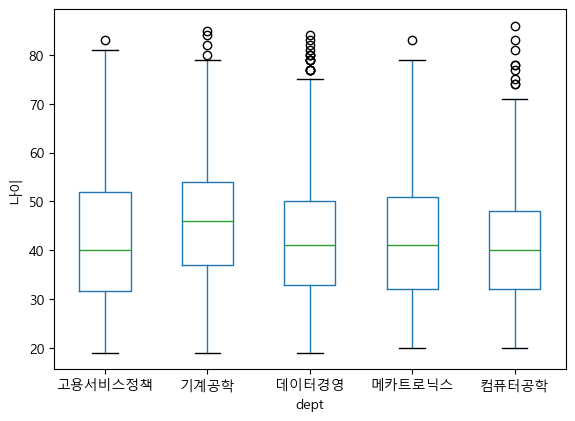

In [26]:
jobs.boxplot(column="age", by="dept", grid=False)
plt.title("")
plt.suptitle("")
plt.ylabel("나이")
plt.show()

상자의 가운데 선이 중앙값, 상자의 위아래가 1사분위와 3사분위다. 상자가 위에 있을수록 나이가 많은 학과다.

## 5. 서술문 읽기와 낱말 세기

숫자만으로는 데이터가 어떤 모습인지 알기 어렵다. 내 직무 사람 3명의 서술문을 읽는다. `random_state`를 고정해서 매번 같은 사람이 나온다.

In [27]:
for _, r in mine.sample(3, random_state=42).iterrows():
    print("=" * 90)
    print(r["occupation"], "|", r["sex"], r["age"], "세 |", r["education_level"])
    print("[직업 페르소나]", r["professional_persona"])
    print("[경력 목표]", r["career_goals_and_ambitions"])

범용 소프트웨어 프로그래머 | 여자 43 세 | 고등학교
[직업 페르소나] 김성아 씨는 교육 현장의 낡고 복잡한 레거시 코드를 논리적으로 분석해 말끔하게 정리하는 데 탁월한 능력을 갖춘 프로그래머입니다. 학습 속도가 느린 아이들이 직관적으로 이해할 수 있는 교육 보조 소프트웨어를 보급하겠다는 목표로 매일 정해진 루틴에 따라 코드를 짭니다.
[경력 목표] 직급 상승이나 권위보다는, 학습 속도가 느린 아이들이 시각적으로 쉽게 이해하고 몰입할 수 있는 직관적인 교육 보조 소프트웨어를 완성해 현장에 보급하는 것에 가치를 둡니다.
시스템 소프트웨어 프로그래머 | 여자 43 세 | 4년제 대학교
[직업 페르소나] 정지연 씨는 출판사 전산실에서 편집자들이 겪는 사소한 불편함까지 잡아내는 시스템 최적화에 몰두하며, 가끔은 낡은 코드와 씨름하다가 혼자 헛웃음을 터뜨리곤 합니다. 복잡한 설계를 실무자가 한눈에 이해하도록 쉽게 풀어내는 능력이 뛰어나 동료들 사이에서 기술적 갈등을 해결하는 부드러운 중재자로 통합니다.
[경력 목표] 현장의 편집자들이 도구에 구애받지 않고 창작에만 몰입할 수 있도록 더 직관적인 저작 시스템을 구축하고 싶어 합니다. 급격한 기술 변화에 매몰되기보다 실질적인 편의를 주는 기술을 현장에 안착시키는 실용적인 전문가를 지향합니다.
그 외 응용 소프트웨어 프로그래머 | 남자 51 세 | 4년제 대학교
[직업 페르소나] 신윤식 씨는 오래된 출판사 관리 시스템의 낡은 코드를 하나하나 다듬으며 정년퇴직까지 무탈한 직장 생활을 꿈꾸는 중년 프로그래머입니다. 후배들의 기술적 고민을 묵묵히 들어주며 팀 내 갈등을 조율하는 중재자 역할을 하지만, 정작 본인의 책상 위는 정돈되지 않은 서류와 엉킨 전선들이 가득합니다.
[경력 목표] 급격한 승진이나 성취보다는 현재의 위치에서 후배들과 원만한 관계를 유지하며 정년까지 무사히 직장 생활을 마치는 것을 최우선으로 생각합니다. 업무적으로는 누군가에게 부담을 주지 않는 선에서 자신의 몫을 다하는 안정적인 상태를 유지하고자 합니다.


### 5-1. 서술문 길이

`str.len()`은 글자 수다. 직무마다 직업 페르소나의 길이 중앙값을 비교한다.

In [28]:
jobs["글자수"] = jobs["professional_persona"].str.len()
jobs.groupby(["dept", "job"])["글자수"].median().sort_values()

dept     job         
기계공학     용접              169.0
         금형·공작기계         171.0
데이터경영    경영 컨설팅·품질       171.0
메카트로닉스   제어·계측           171.0
데이터경영    마케팅·기획          172.0
기계공학     기계공학 기술자        173.0
데이터경영    데이터 분석          173.0
고용서비스정책  인사·노무           173.0
         사회복지            174.0
컴퓨터공학    정보 보안           175.0
메카트로닉스   로봇              175.0
컴퓨터공학    데이터 설계·프로그래밍    175.0
         소프트웨어 개발        175.0
데이터경영    데이터 설계·프로그래밍    176.0
컴퓨터공학    네트워크·시스템        177.0
Name: 글자수, dtype: float64

### 5-2. 특정 낱말이 들어간 비율

`WORD`를 바꿔 가며 어느 직무의 서술문에 그 낱말이 자주 나오는지 본다.

In [29]:
WORD = "고객"
jobs["포함"] = jobs["professional_persona"].str.contains(WORD)
(jobs.groupby(["dept", "job"])["포함"].mean() * 100).round(1).sort_values(ascending=False)

dept     job         
데이터경영    경영 컨설팅·품질       8.6
         마케팅·기획          6.8
기계공학     기계공학 기술자        1.8
컴퓨터공학    소프트웨어 개발        0.4
         네트워크·시스템        0.2
데이터경영    데이터 분석          0.2
고용서비스정책  인사·노무           0.2
컴퓨터공학    정보 보안           0.2
         데이터 설계·프로그래밍    0.2
고용서비스정책  사회복지            0.0
기계공학     금형·공작기계         0.0
         용접              0.0
메카트로닉스   제어·계측           0.0
데이터경영    데이터 설계·프로그래밍    0.0
메카트로닉스   로봇              0.0
Name: 포함, dtype: float64

### 5-3. 기술 목록에서 자주 나오는 낱말

`skills_and_expertise_list`는 `['환자 상태 관찰', '의료 행정']`처럼 리스트 모양의 문자열이다. 작은따옴표 안의 항목을 꺼내고, 띄어쓰기로 쪼개 낱말을 센다. 한 줄이 한 단계다.

In [30]:
skills = mine["skills_and_expertise_list"].str.findall(r"'([^']+)'")   # 작은따옴표 안의 항목을 리스트로 꺼낸다
skills = skills.explode()                                             # 리스트 항목 하나가 행 하나가 되게 펼친다
words = skills.str.split(" ").explode()                               # 항목을 띄어쓰기로 쪼개 낱말 하나가 행 하나
words = words[words.str.len() >= 2]                                   # '및' 같은 한 글자는 뺀다
words = words[~words.isin(["관리", "기술", "능력", "활용", "통한", "위한"])]   # 어느 직무에나 나오는 낱말은 뺀다
words.value_counts().head(20)                                         # 많은 순 20개

skills_and_expertise_list
최적화       456
설계        429
시스템       349
기반        283
분석        218
데이터베이스    210
개발        184
사용자       174
레거시       146
소프트웨어     141
코드        136
교육        133
유지보수      121
자바        120
구현        113
인터페이스     109
교육용       109
쿼리        108
요구사항      105
작성        103
Name: count, dtype: int64

`MY_DEPT`, `MY_JOB`을 바꿔 4-1부터 다시 실행하면 다른 직무의 낱말이 나온다. 직무마다 앞자리에 오는 낱말이 다른지 비교해 본다.

## 읽을 때 주의할 점

- 이 데이터는 실제 사람이 아니라 **합성 데이터**다. 등장인물은 모두 가상이고, 서술문은 LLM이 인구통계 변수를 보고 쓴 것이다.
- `dept`와 `job`은 직업명에서 낱말을 찾아 붙인 학습용 컬럼이다. 실제 학과 졸업생의 진로 통계가 아니다.
- 표본이라 전체와 비율이 다를 수 있다.

## 더 해 보기

- 전체 데이터(100만 명, 2GB)로 같은 분석을 하려면 [실습 노트북(확장편)](https://kwonsuhyeon.github.io/personaex/quickstart.html)을 본다. 거기서는 polars를 쓰고, 직무를 직업명 검색으로 직접 고른다.
- 노트북에 나온 문법이 낯설면 [Python 기초 문법](https://kwonsuhyeon.github.io/personaex/python-basics.html)을 본다.
- 표본이 어떻게 만들어졌는지는 [표본 설명](https://kwonsuhyeon.github.io/personaex/data/README.md)에 있다.